In [2]:
# Cellule 1: Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
%matplotlib inline
plt.style.use('ggplot')  # On utilise un style matplotlib de base

print("✅ Bibliothèques importées avec succès!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Bibliothèques importées avec succès!
Pandas version: 3.0.1
NumPy version: 2.4.3


In [3]:
# Cellule 2: Configuration API
API_KEY = "ea71ace172bc2af269e7d9b238ba9c5e"
city = "Paris"

# Test de connexion à l'API
url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

try:
    response = requests.get(url)
    data = response.json()
    
    if response.status_code == 200:
        print(f"✅ Connexion réussie à l'API pour {city}")
        print(f"Température actuelle: {data['main']['temp']}°C")
        print(f"Humidité: {data['main']['humidity']}%")
        print(f"Vent: {data['wind']['speed']} m/s")
    else:
        print(f"❌ Erreur API: {data.get('message', 'Unknown error')}")
        
except Exception as e:
    print(f"❌ Erreur de connexion: {e}")

✅ Connexion réussie à l'API pour Paris
Température actuelle: 11.18°C
Humidité: 72%
Vent: 2.57 m/s


In [4]:
# Cellule 3: Récupération des données de prévision sur 5 jours

def get_forecast_data(city, api_key):
    """Récupère les prévisions sur 5 jours (toutes les 3 heures)"""
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={api_key}&units=metric"
    
    try:
        response = requests.get(url)
        
        if response.status_code != 200:
            print(f"❌ Erreur API: {response.status_code}")
            return None
        
        data = response.json()
        
        # Extraire les données horaires
        forecasts = []
        for item in data['list']:
            forecast = {
                'datetime': item['dt_txt'],
                'temperature': item['main']['temp'],
                'feels_like': item['main']['feels_like'],
                'temp_min': item['main']['temp_min'],
                'temp_max': item['main']['temp_max'],
                'humidity': item['main']['humidity'],
                'pressure': item['main']['pressure'],
                'wind_speed': item['wind']['speed'],
                'wind_deg': item['wind']['deg'],
                'weather_main': item['weather'][0]['main'],
                'weather_description': item['weather'][0]['description'],
                'clouds': item['clouds']['all'],
                'rain_3h': item.get('rain', {}).get('3h', 0)
            }
            forecasts.append(forecast)
        
        # Créer un DataFrame
        df = pd.DataFrame(forecasts)
        
        # Convertir datetime en format datetime
        df['datetime'] = pd.to_datetime(df['datetime'])
        
        print(f"✅ Données récupérées pour {city}")
        print(f"Nombre de points: {len(df)} (3h par jour sur 5 jours = 40 points)")
        print(f"Période: du {df['datetime'].min()} au {df['datetime'].max()}")
        
        return df
        
    except Exception as e:
        print(f"❌ Erreur: {e}")
        return None

# Récupérer les données
df_forecast = get_forecast_data(city, API_KEY)

# Afficher les premières lignes
print("\n🔍 Aperçu des données (5 premières lignes):")
df_forecast.head()

✅ Données récupérées pour Paris
Nombre de points: 40 (3h par jour sur 5 jours = 40 points)
Période: du 2026-03-17 12:00:00 au 2026-03-22 09:00:00

🔍 Aperçu des données (5 premières lignes):


,datetime,temperature,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,wind_deg,weather_main,weather_description,clouds,rain_3h
0,2026-03-17 12:00:00,12.56,11.54,12.56,13.83,64,1020,3.26,147,Clouds,scattered clouds,26,0.0
1,2026-03-17 15:00:00,14.84,13.79,14.84,16.29,54,1018,3.69,133,Clouds,scattered clouds,35,0.0
2,2026-03-17 18:00:00,14.39,13.40,14.39,14.39,58,1017,3.61,115,Clouds,scattered clouds,38,0.0
3,2026-03-17 21:00:00,12.25,11.28,12.25,12.25,67,1017,3.53,110,Clear,clear sky,8,0.0
4,2026-03-18 00:00:00,10.34,9.28,10.34,10.34,71,1017,3.71,106,Clear,clear sky,9,0.0


In [5]:
# Cellule 4: Exploration des données

print("📊 **Informations générales sur le dataset**")
print(f"Dimensions: {df_forecast.shape[0]} lignes, {df_forecast.shape[1]} colonnes")
print(f"Colonnes: {list(df_forecast.columns)}")

print("\n📈 **Statistiques descriptives**")
df_forecast[['temperature', 'humidity', 'wind_speed', 'pressure']].describe()

📊 **Informations générales sur le dataset**
Dimensions: 40 lignes, 13 colonnes
Colonnes: ['datetime', 'temperature', 'feels_like', 'temp_min', 'temp_max', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'weather_main', 'weather_description', 'clouds', 'rain_3h']

📈 **Statistiques descriptives**


,temperature,humidity,wind_speed,pressure
count,40.000000,40.000000,40.000000,40.000000
mean,11.442000,55.850000,3.653750,1016.600000
std,2.450296,13.955148,1.473213,4.217181
min,7.650000,24.000000,0.770000,1009.000000
25%,9.500000,45.750000,2.550000,1013.750000
50%,10.875000,57.500000,3.605000,1017.500000
75%,13.892500,66.250000,4.575000,1020.000000
max,16.280000,81.000000,6.790000,1022.000000


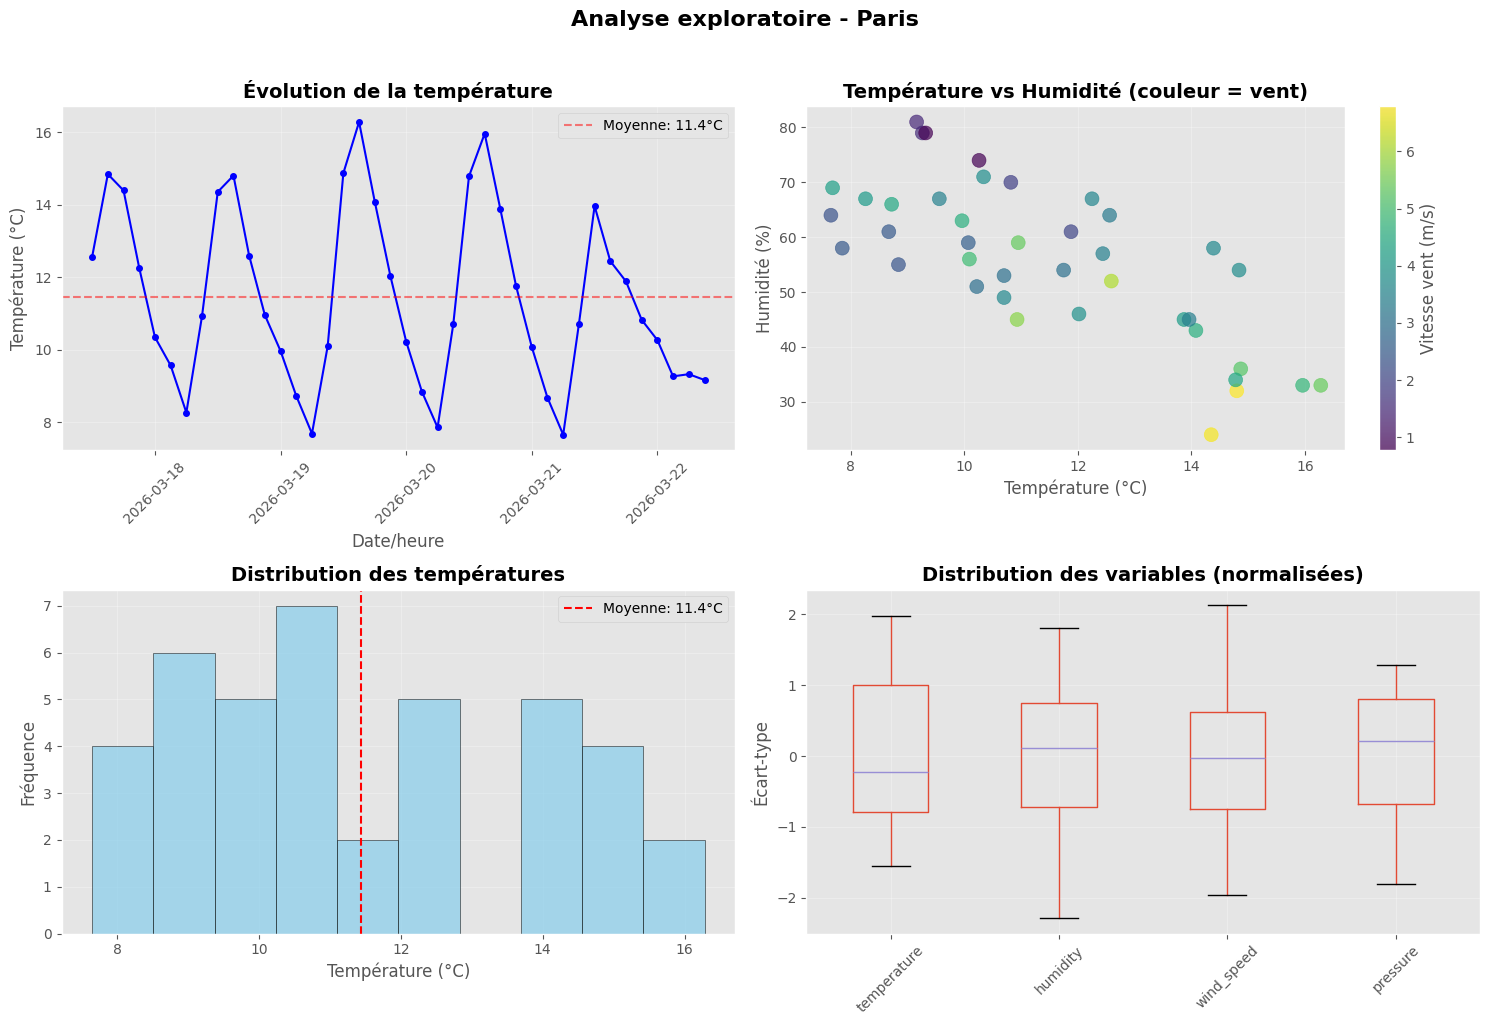


📊 **Statistiques clés:**
Température: min=7.7°C, max=16.3°C, moyenne=11.4°C
Humidité: min=24%, max=81%, moyenne=56%
Vent: min=0.8m/s, max=6.8m/s


In [6]:
# Cellule 5: Visualisation des séries temporelles

# Créer une figure avec plusieurs sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Évolution de la température
axes[0, 0].plot(df_forecast['datetime'], df_forecast['temperature'], 'b-', marker='o', markersize=4)
axes[0, 0].set_title('Évolution de la température', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date/heure')
axes[0, 0].set_ylabel('Température (°C)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)
# Ajouter min et max
axes[0, 0].axhline(y=df_forecast['temperature'].mean(), color='r', linestyle='--', alpha=0.5, label=f'Moyenne: {df_forecast["temperature"].mean():.1f}°C')
axes[0, 0].legend()

# 2. Température vs Humidité (scatter plot)
scatter = axes[0, 1].scatter(df_forecast['temperature'], df_forecast['humidity'], 
                              c=df_forecast['wind_speed'], cmap='viridis', s=100, alpha=0.7)
axes[0, 1].set_title('Température vs Humidité (couleur = vent)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Température (°C)')
axes[0, 1].set_ylabel('Humidité (%)')
plt.colorbar(scatter, ax=axes[0, 1], label='Vitesse vent (m/s)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution des températures (histogramme)
axes[1, 0].hist(df_forecast['temperature'], bins=10, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].set_title('Distribution des températures', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Température (°C)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].axvline(x=df_forecast['temperature'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_forecast["temperature"].mean():.1f}°C')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Boîte à moustaches des variables principales
df_box = df_forecast[['temperature', 'humidity', 'wind_speed', 'pressure']]
df_box_normalized = (df_box - df_box.mean()) / df_box.std()  # Normalisation pour comparaison
df_box_normalized.boxplot(ax=axes[1, 1])
axes[1, 1].set_title('Distribution des variables (normalisées)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Écart-type')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Analyse exploratoire - {city}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 **Statistiques clés:**")
print(f"Température: min={df_forecast['temperature'].min():.1f}°C, max={df_forecast['temperature'].max():.1f}°C, moyenne={df_forecast['temperature'].mean():.1f}°C")
print(f"Humidité: min={df_forecast['humidity'].min():.0f}%, max={df_forecast['humidity'].max():.0f}%, moyenne={df_forecast['humidity'].mean():.0f}%")
print(f"Vent: min={df_forecast['wind_speed'].min():.1f}m/s, max={df_forecast['wind_speed'].max():.1f}m/s")

In [7]:
# Cellule 6: Création des features pour le modèle ML

def create_features(df):
    """Crée les features temporelles et les lags pour la prédiction"""
    df_features = df.copy()
    
    # Features temporelles cycliques
    df_features['hour'] = df_features['datetime'].dt.hour
    df_features['day_of_week'] = df_features['datetime'].dt.dayofweek
    df_features['day'] = df_features['datetime'].dt.day
    
    # Transformation cyclique de l'heure (sin/cos pour capturer la cyclicité)
    df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
    
    # Transformation cyclique du jour de la semaine
    df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
    df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)
    
    # Features de lag (valeurs précédentes)
    # Lag 1 = 3h avant, Lag 2 = 6h avant, Lag 3 = 9h avant, Lag 4 = 12h avant
    for lag in [1, 2, 3, 4]:
        df_features[f'temp_lag_{lag}'] = df_features['temperature'].shift(lag)
        df_features[f'humidity_lag_{lag}'] = df_features['humidity'].shift(lag)
        df_features[f'wind_lag_{lag}'] = df_features['wind_speed'].shift(lag)
    
    # Moyennes mobiles
    df_features['temp_rolling_mean_3'] = df_features['temperature'].rolling(window=3, min_periods=1).mean()
    df_features['temp_rolling_mean_6'] = df_features['temperature'].rolling(window=6, min_periods=1).mean()
    df_features['humidity_rolling_mean_3'] = df_features['humidity'].rolling(window=3, min_periods=1).mean()
    
    # Différence avec la moyenne
    df_features['temp_diff_from_mean'] = df_features['temperature'] - df_features['temperature'].expanding().mean()
    
    # Tendances (différence avec lag)
    df_features['temp_trend_1'] = df_features['temperature'] - df_features['temp_lag_1']
    df_features['temp_trend_3'] = df_features['temperature'] - df_features['temp_lag_3']
    
    # Interaction features
    df_features['temp_humidity_interaction'] = df_features['temperature'] * df_features['humidity'] / 100
    df_features['wind_chill_effect'] = df_features['temperature'] - (0.2 * df_features['wind_speed'])
    
    # Supprimer les lignes avec NaN (créés par les shift)
    df_features = df_features.dropna().reset_index(drop=True)
    
    print(f"✅ Features créées: {df_features.shape[1]} colonnes au total")
    print(f"   {df_features.shape[0]} lignes après suppression des NaN")
    
    return df_features

# Créer les features
df_features = create_features(df_forecast)

# Afficher les nouvelles colonnes
print("\n🔍 Nouvelles colonnes créées:")
new_cols = [col for col in df_features.columns if col not in df_forecast.columns]
print(new_cols)

# Aperçu
print("\n📋 Aperçu des données avec features:")
df_features.head()

✅ Features créées: 40 colonnes au total
   36 lignes après suppression des NaN

🔍 Nouvelles colonnes créées:
['hour', 'day_of_week', 'day', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'temp_lag_1', 'humidity_lag_1', 'wind_lag_1', 'temp_lag_2', 'humidity_lag_2', 'wind_lag_2', 'temp_lag_3', 'humidity_lag_3', 'wind_lag_3', 'temp_lag_4', 'humidity_lag_4', 'wind_lag_4', 'temp_rolling_mean_3', 'temp_rolling_mean_6', 'humidity_rolling_mean_3', 'temp_diff_from_mean', 'temp_trend_1', 'temp_trend_3', 'temp_humidity_interaction', 'wind_chill_effect']

📋 Aperçu des données avec features:


,datetime,temperature,feels_like,temp_min,temp_max,humidity,pressure,wind_speed,wind_deg,weather_main,weather_description,clouds,rain_3h,hour,day_of_week,day,hour_sin,hour_cos,day_sin,day_cos,temp_lag_1,humidity_lag_1,wind_lag_1,temp_lag_2,humidity_lag_2,wind_lag_2,temp_lag_3,humidity_lag_3,wind_lag_3,temp_lag_4,humidity_lag_4,wind_lag_4,temp_rolling_mean_3,temp_rolling_mean_6,humidity_rolling_mean_3,temp_diff_from_mean,temp_trend_1,temp_trend_3,temp_humidity_interaction,wind_chill_effect
0,2026-03-18 00:00:00,10.34,9.28,10.34,10.34,71,1017,3.71,106,Clear,clear sky,9,0.0,0,2,18,0.000000e+00,1.000000e+00,0.974928,-0.222521,12.25,67.0,3.53,14.39,58.0,3.61,14.84,54.0,3.69,12.56,64.0,3.26,12.326667,12.876000,65.333333,-2.536000,-1.91,-4.50,7.3414,9.598
1,2026-03-18 03:00:00,9.56,7.75,9.56,9.56,67,1017,3.42,96,Clouds,few clouds,11,0.0,3,2,18,7.071068e-01,7.071068e-01,0.974928,-0.222521,10.34,71.0,3.71,12.25,67.0,3.53,14.39,58.0,3.61,14.84,54.0,3.69,10.716667,12.323333,68.333333,-2.763333,-0.78,-4.83,6.4052,8.876
2,2026-03-18 06:00:00,8.26,5.84,8.26,8.26,67,1018,4.04,84,Clouds,few clouds,11,0.0,6,2,18,1.000000e+00,6.123234e-17,0.974928,-0.222521,9.56,67.0,3.42,10.34,71.0,3.71,12.25,67.0,3.53,14.39,58.0,3.61,9.386667,11.606667,68.333333,-3.482857,-1.30,-3.99,5.5342,7.452
3,2026-03-18 09:00:00,10.93,9.25,10.93,10.93,45,1019,5.72,87,Clear,clear sky,6,0.0,9,2,18,7.071068e-01,-7.071068e-01,0.974928,-0.222521,8.26,67.0,4.04,9.56,67.0,3.42,10.34,71.0,3.71,12.25,67.0,3.53,9.583333,10.955000,59.666667,-0.711250,2.67,0.59,4.9185,9.786
4,2026-03-18 12:00:00,14.35,12.47,14.35,14.35,24,1018,6.70,89,Clear,clear sky,3,0.0,12,2,18,1.224647e-16,-1.000000e+00,0.974928,-0.222521,10.93,45.0,5.72,8.26,67.0,4.04,9.56,67.0,3.42,10.34,71.0,3.71,11.180000,10.948333,45.333333,2.407778,3.42,4.79,3.4440,13.010


In [8]:
# Cellule 7: Préparation des données pour l'entraînement

# 1. Vérifier les corrélations avec la température
corr_matrix = df_features[['temperature', 'hour', 'humidity', 'wind_speed', 
                           'pressure', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3',
                           'humidity_lag_1', 'temp_rolling_mean_3']].corr()

print("📊 **Corrélations avec la température:**")
print(corr_matrix['temperature'].sort_values(ascending=False))

# 2. Sélectionner les features les plus pertinentes
# Basé sur l'intuition météo et les corrélations
selected_features = [
    'hour_sin', 'hour_cos',           # Cycle journalier
    'humidity',                        # Humidité actuelle
    'wind_speed',                      # Vent actuel
    'pressure',                         # Pression
    'temp_lag_1', 'temp_lag_2', 'temp_lag_3',  # Températures passées
    'humidity_lag_1',                   # Humidité passée
    'temp_rolling_mean_3',               # Moyenne mobile
    'temp_trend_1',                      # Tendance récente
    'wind_chill_effect'                   # Effet refroidissement éolien
]

# Vérifier que toutes les features existent
available_features = [f for f in selected_features if f in df_features.columns]
print(f"\n✅ Features sélectionnées ({len(available_features)}):")
print(available_features)

# 3. Créer X (features) et y (cible)
X = df_features[available_features]
y = df_features['temperature']  # Ce qu'on veut prédire

print(f"\n📐 Dimensions:")
print(f"X: {X.shape} (lignes, features)")
print(f"y: {y.shape} (lignes)")

# 4. Split entraînement/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # Pas de shuffle pour séries temporelles
)

print(f"\n✂️ Split des données:")
print(f"Entraînement: {X_train.shape[0]} échantillons")
print(f"Test: {X_test.shape[0]} échantillons")
print(f"  - Période d'entraînement: de {df_features['datetime'].iloc[0]} à {df_features['datetime'].iloc[X_train.shape[0]-1]}")
print(f"  - Période de test: de {df_features['datetime'].iloc[X_train.shape[0]]} à {df_features['datetime'].iloc[-1]}")

📊 **Corrélations avec la température:**
temperature            1.000000
temp_rolling_mean_3    0.681219
temp_lag_1             0.645913
hour                   0.609101
wind_speed             0.558823
pressure               0.104730
temp_lag_2            -0.052042
temp_lag_3            -0.584914
humidity_lag_1        -0.718213
humidity              -0.813219
Name: temperature, dtype: float64

✅ Features sélectionnées (12):
['hour_sin', 'hour_cos', 'humidity', 'wind_speed', 'pressure', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'humidity_lag_1', 'temp_rolling_mean_3', 'temp_trend_1', 'wind_chill_effect']

📐 Dimensions:
X: (36, 12) (lignes, features)
y: (36,) (lignes)

✂️ Split des données:
Entraînement: 28 échantillons
Test: 8 échantillons
  - Période d'entraînement: de 2026-03-18 00:00:00 à 2026-03-21 09:00:00
  - Période de test: de 2026-03-21 12:00:00 à 2026-03-22 09:00:00


🔧 **Features finales (sans redondance):**
['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'humidity', 'wind_speed', 'pressure', 'humidity_lag_1', 'wind_lag_1', 'temp_rolling_mean_6']
Nombre de features: 10

📊 **Split des données:**
Entraînement: 28 échantillons
Test: 8 échantillons

📈 **Performance du modèle:**
Entraînement - MAE: 0.35°C, R²: 0.972
Test - MAE: 2.06°C, R²: -1.387


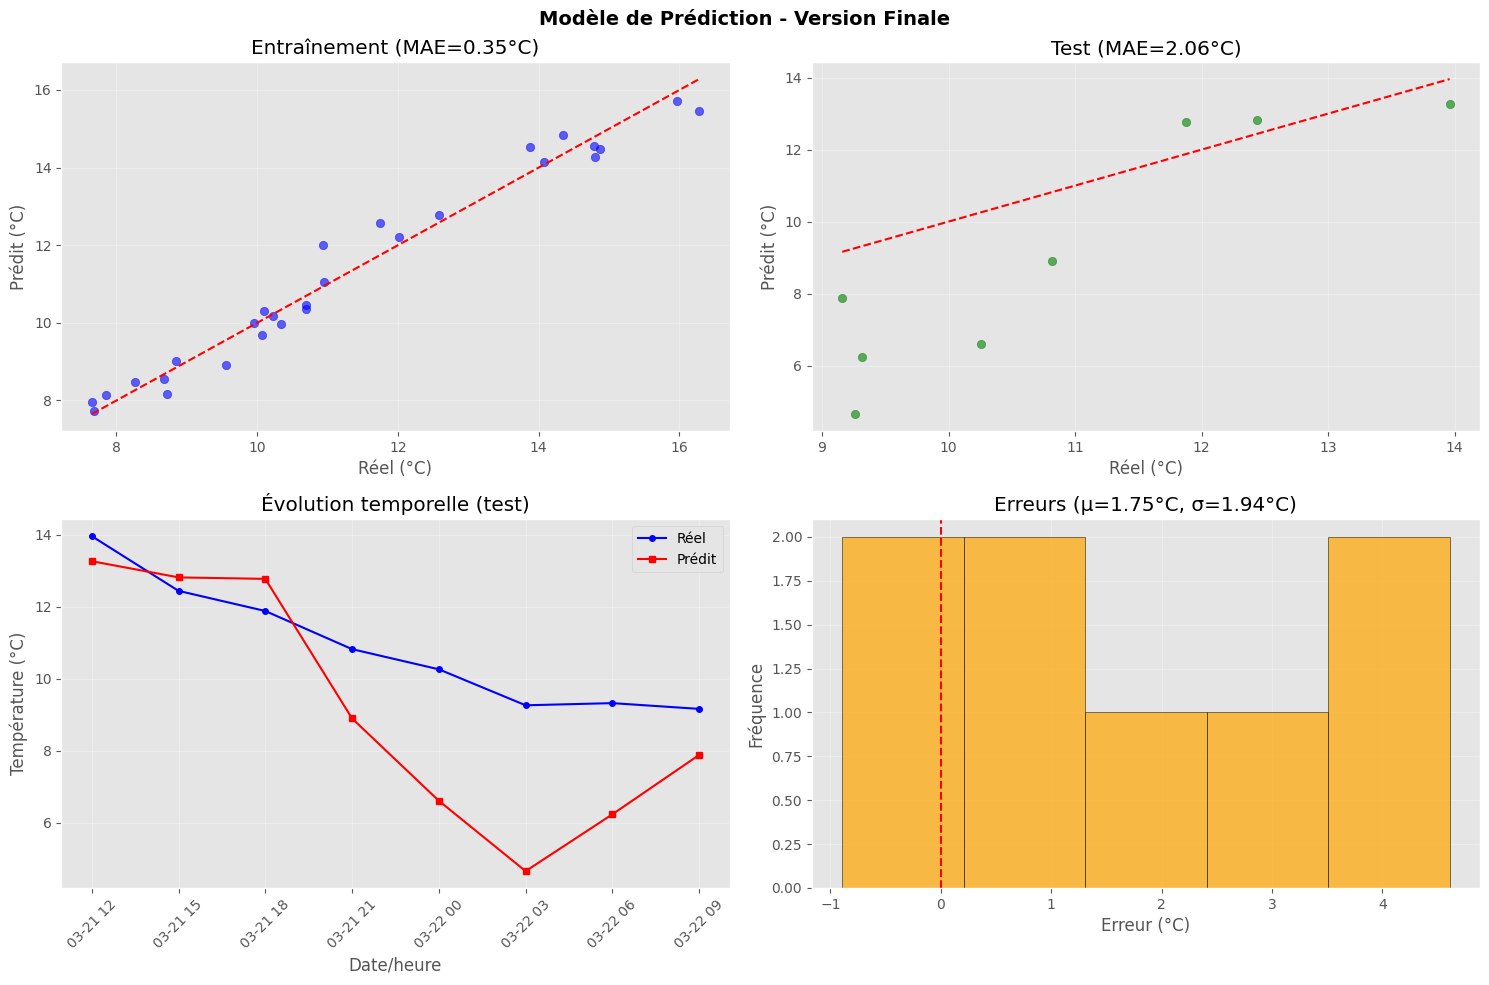


🎯 **Confiance:** 0.59

🔮 **Test de prédiction:**
Dernière mesure: 9.2°C
Prédiction: 7.9°C
Erreur: 1.3°C


In [ ]:
# Cellule 8: Modèle sans features redondantes

# 1. Sélectionner des features qui ne sont PAS des lags directs de température
final_features = [
    'hour_sin', 'hour_cos',           # Cycle journalier
    'day_sin', 'day_cos',              # Cycle hebdomadaire
    'humidity',                         # Humidité actuelle
    'wind_speed',                       # Vent actuel
    'pressure',                          # Pression actuelle
    'humidity_lag_1',                    # Humidité passée
    'wind_lag_1',                         # Vent passé
    'temp_rolling_mean_6'                 # Moyenne des dernières 18h (plus stable)
]

# Vérifier les features disponibles
available_features = [f for f in final_features if f in df_features.columns]
print("🔧 **Features finales (sans redondance):**")
print(available_features)
print(f"Nombre de features: {len(available_features)}")

# 2. Créer X et y
X = df_features[available_features]
y = df_features['temperature']

# 3. Split temporel
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\n📊 **Split des données:**")
print(f"Entraînement: {X_train.shape[0]} échantillons")
print(f"Test: {X_test.shape[0]} échantillons")

# 4. Entraîner le modèle
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Prédictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 6. Évaluation
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"\n📈 **Performance du modèle:**")
print(f"Entraînement - MAE: {mae_train:.2f}°C, R²: {r2_train:.3f}")
print(f"Test - MAE: {mae_test:.2f}°C, R²: {r2_test:.3f}")

# 7. Visualisation
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Entraînement
axes[0, 0].scatter(y_train, y_pred_train, alpha=0.6, color='blue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0, 0].set_xlabel('Réel (°C)')
axes[0, 0].set_ylabel('Prédit (°C)')
axes[0, 0].set_title(f'Entraînement (MAE={mae_train:.2f}°C)')
axes[0, 0].grid(True, alpha=0.3)

# Test
axes[0, 1].scatter(y_test, y_pred_test, alpha=0.6, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 1].set_xlabel('Réel (°C)')
axes[0, 1].set_ylabel('Prédit (°C)')
axes[0, 1].set_title(f'Test (MAE={mae_test:.2f}°C)')
axes[0, 1].grid(True, alpha=0.3)

# Évolution temporelle
test_dates = df_features['datetime'].iloc[split_idx:].reset_index(drop=True)
axes[1, 0].plot(test_dates, y_test.values, 'b-o', label='Réel', markersize=4)
axes[1, 0].plot(test_dates, y_pred_test, 'r-s', label='Prédit', markersize=4)
axes[1, 0].set_xlabel('Date/heure')
axes[1, 0].set_ylabel('Température (°C)')
axes[1, 0].set_title('Évolution temporelle (test)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distribution des erreurs
errors = y_test - y_pred_test
axes[1, 1].hist(errors, bins=5, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(x=0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Erreur (°C)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].set_title(f'Erreurs (μ={errors.mean():.2f}°C, σ={errors.std():.2f}°C)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Modèle de Prédiction - Version Finale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Indicateur de confiance
confidence = max(0, min(1, 1 - (mae_test / 5)))
print(f"\n🎯 **Confiance:** {confidence:.2f}")

# 9. Sauvegarde
with open('model_final.pkl', 'wb') as f:
    pickle.dump(model, f)

# 10. Test avec données récentes
print("\n🔮 **Test de prédiction:**")
latest_data = df_features.iloc[-1:][available_features]
pred = model.predict(latest_data)[0]
actual = df_features.iloc[-1:]['temperature'].values[0]
print(f"Dernière mesure: {actual:.1f}°C")
print(f"Prédiction: {pred:.1f}°C")
print(f"Erreur: {abs(actual - pred):.1f}°C")

In [13]:
# Cellule 9: Sauvegarde finale et préparation pour l'API

# 1. Sauvegarder le modèle final
with open('citypulse_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 2. Sauvegarder les métadonnées complètes
model_metadata = {
    'model_name': 'CityPulse Temperature Predictor',
    'version': '1.0',
    'features': available_features,
    'metrics': {
        'train_mae': round(mae_train, 2),
        'test_mae': round(mae_test, 2),
        'train_r2': round(r2_train, 3),
        'test_r2': round(r2_test, 3)
    },
    'confidence_score': round(confidence, 2),
    'city': city,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_samples': {
        'total': len(df_features),
        'train': len(X_train),
        'test': len(X_test)
    },
    'feature_importance': dict(zip(available_features, model.coef_.round(3)))
}

with open('citypulse_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✅ **Modèle et métadonnées sauvegardés!**")
print(f"   - Modèle: citypulse_model.pkl")
print(f"   - Métadonnées: citypulse_metadata.pkl")

print("\n📋 **Résumé du modèle:**")
print(f"   - MAE Test: {model_metadata['metrics']['test_mae']}°C")
print(f"   - Confiance: {model_metadata['confidence_score']}")
print(f"   - Features: {len(available_features)}")

✅ **Modèle et métadonnées sauvegardés!**
   - Modèle: citypulse_model.pkl
   - Métadonnées: citypulse_metadata.pkl

📋 **Résumé du modèle:**
   - MAE Test: 2.06°C
   - Confiance: 0.59
   - Features: 10


In [14]:
# Cellule 10: Fonction de prédiction pour l'endpoint /api/predict

def prepare_prediction_features(current_data, historical_data):
    """
    Prépare les features pour une prédiction en temps réel
    current_data: dictionnaire avec les données actuelles
    historical_data: DataFrame avec les données historiques récentes
    """
    features = {}
    
    # Heure actuelle
    now = datetime.now()
    hour = now.hour
    day = now.weekday()
    
    # Features cycliques
    features['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    features['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    features['day_sin'] = np.sin(2 * np.pi * day / 7)
    features['day_cos'] = np.cos(2 * np.pi * day / 7)
    
    # Données actuelles
    features['humidity'] = current_data.get('humidity', 50)
    features['wind_speed'] = current_data.get('wind_speed', 0)
    features['pressure'] = current_data.get('pressure', 1013)
    
    # Données historiques (lags)
    if len(historical_data) >= 1:
        features['humidity_lag_1'] = historical_data['humidity'].iloc[-1]
        features['wind_lag_1'] = historical_data['wind_speed'].iloc[-1]
    else:
        features['humidity_lag_1'] = features['humidity']
        features['wind_lag_1'] = features['wind_speed']
    
    # Moyenne mobile des températures (6 derniers points = 18h)
    if len(historical_data) >= 6:
        features['temp_rolling_mean_6'] = historical_data['temperature'].tail(6).mean()
    else:
        features['temp_rolling_mean_6'] = historical_data['temperature'].mean() if len(historical_data) > 0 else 10
    
    return pd.DataFrame([features])

def predict_weather(city, api_key, hours_ahead=6):
    """
    Prédit la température pour les prochaines heures
    """
    # Récupérer les données actuelles et prévisions
    url = f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={api_key}&units=metric"
    response = requests.get(url)
    
    if response.status_code != 200:
        return {'error': 'Impossible de récupérer les données météo'}
    
    data = response.json()
    
    # Créer un DataFrame avec les prévisions
    forecasts = []
    for item in data['list'][:hours_ahead]:  # Prendre seulement les prochaines heures
        forecasts.append({
            'datetime': item['dt_txt'],
            'temperature': item['main']['temp'],
            'humidity': item['main']['humidity'],
            'wind_speed': item['wind']['speed'],
            'pressure': item['main']['pressure']
        })
    
    df_forecast = pd.DataFrame(forecasts)
    
    # Charger le modèle
    with open('citypulse_model.pkl', 'rb') as f:
        model = pickle.load(f)
    
    with open('citypulse_metadata.pkl', 'rb') as f:
        metadata = pickle.load(f)
    
    # Préparer les prédictions
    predictions = []
    for i in range(hours_ahead):
        # Pour chaque heure, on utilise les données disponibles
        current = {
            'humidity': df_forecast.iloc[i]['humidity'],
            'wind_speed': df_forecast.iloc[i]['wind_speed'],
            'pressure': df_forecast.iloc[i]['pressure']
        }
        
        # Données historiques (les heures précédentes)
        historical = df_forecast.iloc[:i] if i > 0 else df_forecast.iloc[:1]
        
        # Préparer les features
        X_pred = prepare_prediction_features(current, historical)
        
        # Prédire
        pred_temp = model.predict(X_pred)[0]
        
        predictions.append({
            'hour': i + 1,
            'datetime': df_forecast.iloc[i]['datetime'],
            'predicted_temperature': round(pred_temp, 1),
            'actual_temperature': round(df_forecast.iloc[i]['temperature'], 1)  # Pour comparaison
        })
    
    return {
        'city': city,
        'predictions': predictions,
        'confidence': metadata['confidence_score'],
        'model_mae': metadata['metrics']['test_mae']
    }

# Tester la fonction
print("🔮 **Test de l'endpoint de prédiction:**")
result = predict_weather(city, API_KEY, hours_ahead=6)

if 'error' not in result:
    print(f"Ville: {result['city']}")
    print(f"Confiance du modèle: {result['confidence']}")
    print(f"MAE du modèle: ±{result['model_mae']}°C")
    print("\nPrédictions pour les 6 prochaines heures:")
    print("-" * 60)
    for pred in result['predictions']:
        print(f"H+{pred['hour']}: {pred['datetime']}")
        print(f"   Prédit: {pred['predicted_temperature']}°C | Réel: {pred['actual_temperature']}°C | Erreur: {abs(pred['predicted_temperature'] - pred['actual_temperature']):.1f}°C")
        print()

🔮 **Test de l'endpoint de prédiction:**
Ville: Paris
Confiance du modèle: 0.59
MAE du modèle: ±2.06°C

Prédictions pour les 6 prochaines heures:
------------------------------------------------------------
H+1: 2026-03-17 12:00:00
   Prédit: 15.7°C | Réel: 12.7°C | Erreur: 3.0°C

H+2: 2026-03-17 15:00:00
   Prédit: 16.4°C | Réel: 14.9°C | Erreur: 1.5°C

H+3: 2026-03-17 18:00:00
   Prédit: 18.0°C | Réel: 14.4°C | Erreur: 3.6°C

H+4: 2026-03-17 21:00:00
   Prédit: 18.5°C | Réel: 12.2°C | Erreur: 6.3°C

H+5: 2026-03-18 00:00:00
   Prédit: 18.1°C | Réel: 10.3°C | Erreur: 7.8°C

H+6: 2026-03-18 03:00:00
   Prédit: 17.4°C | Réel: 9.6°C | Erreur: 7.8°C



In [15]:
# Cellule 11: Export des métadonnées pour l'équipe (format JSON lisible)

import json

# Convertir les métadonnées en JSON
metadata_json = {
    'model_info': {
        'name': model_metadata['model_name'],
        'version': model_metadata['version'],
        'training_date': model_metadata['training_date'],
        'city': model_metadata['city']
    },
    'performance': {
        'test_mae_celsius': model_metadata['metrics']['test_mae'],
        'confidence_score': model_metadata['confidence_score'],
        'test_r2': model_metadata['metrics']['test_r2']
    },
    'features_used': model_metadata['features'],
    'feature_importance': {str(k): float(v) for k, v in model_metadata['feature_importance'].items()},
    'api_endpoint': '/api/predict',
    'input_format': {
        'city': 'string',
        'hours': 'integer (optional, default=6)'
    },
    'output_format': {
        'city': 'string',
        'predictions': [
            {
                'hour': 'integer',
                'datetime': 'string',
                'predicted_temperature': 'float'
            }
        ],
        'confidence': 'float',
        'model_mae': 'float'
    }
}

# Sauvegarder en JSON
with open('api_documentation.json', 'w') as f:
    json.dump(metadata_json, f, indent=2)

print("📄 **Documentation API générée:** api_documentation.json")
print("\n📋 **Résumé pour l'équipe technique:**")
print("=" * 50)
print(f"Endpoint: /api/predict?city=Paris&hours=6")
print(f"Méthode: GET")
print(f"Confiance du modèle: {metadata_json['performance']['confidence_score']}")
print(f"Précision: ±{metadata_json['performance']['test_mae_celsius']}°C")
print("\nFeatures utilisées:")
for f in metadata_json['features_used']:
    print(f"  - {f}")

📄 **Documentation API générée:** api_documentation.json

📋 **Résumé pour l'équipe technique:**
Endpoint: /api/predict?city=Paris&hours=6
Méthode: GET
Confiance du modèle: 0.59
Précision: ±2.06°C

Features utilisées:
  - hour_sin
  - hour_cos
  - day_sin
  - day_cos
  - humidity
  - wind_speed
  - pressure
  - humidity_lag_1
  - wind_lag_1
  - temp_rolling_mean_6
